In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import googlenet, GoogLeNet_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR = r"/content/drive/MyDrive/Deep Learning/split_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

/content/drive/MyDrive/Deep Learning/split_dataset/train
/content/drive/MyDrive/Deep Learning/split_dataset/val
/content/drive/MyDrive/Deep Learning/split_dataset/test


In [4]:
weights = GoogLeNet_Weights.DEFAULT

print(weights)

GoogLeNet_Weights.IMAGENET1K_V1


In [5]:
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std
    )
])

In [8]:
val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std
    )
])

In [9]:
train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Deep Learning/split_dataset/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Deep Learning/split_dataset/val",
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Deep Learning/split_dataset/test",
    transform=val_transform
)

In [10]:
print("Classes:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

print("\nDataset size:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes:
['lung_aca', 'lung_n', 'lung_scc']

Class mapping:
{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}

Dataset size:
Train: 1680
Validation: 360
Test: 360


In [11]:
from collections import Counter

train_counts = Counter(
    train_dataset.targets
)

val_counts = Counter(
    val_dataset.targets
)

test_counts = Counter(
    test_dataset.targets
)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: Counter({0: 560, 1: 560, 2: 560})
Validation: Counter({0: 120, 1: 120, 2: 120})
Test: Counter({0: 120, 1: 120, 2: 120})


In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

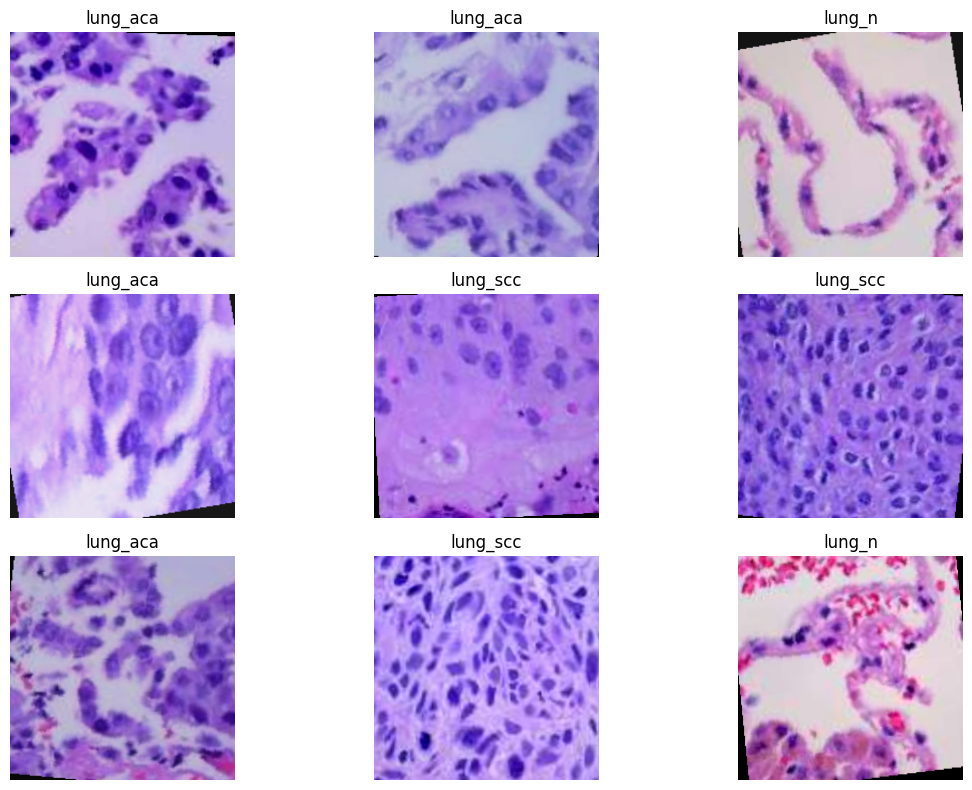

In [13]:
images, labels = next(
    iter(train_loader)
)

plt.figure(figsize=(12, 8))

mean = torch.tensor(
    [0.485, 0.456, 0.406]
)

std = torch.tensor(
    [0.229, 0.224, 0.225]
)

for i in range(9):

    image = images[i].permute(
        1, 2, 0
    )

    image = image * std + mean

    image = image.clamp(
        0, 1
    )

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        train_dataset.classes[
            labels[i]
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
model = googlenet(
    weights=GoogLeNet_Weights.DEFAULT,
    aux_logits=True
)

print(model)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 181MB/s]


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [15]:
for param in model.parameters():
    param.requires_grad = False

In [16]:
num_classes = 3

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model.aux1.fc2 = nn.Linear(
    model.aux1.fc2.in_features,
    num_classes
)

model.aux2.fc2 = nn.Linear(
    model.aux2.fc2.in_features,
    num_classes
)

In [17]:
for param in model.fc.parameters():
    param.requires_grad = True

for param in model.aux1.fc2.parameters():
    param.requires_grad = True

for param in model.aux2.fc2.parameters():
    param.requires_grad = True

In [18]:
model = model.to(device)

print("Model loaded successfully.")

Model loaded successfully.


In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.001,
    weight_decay=1e-4
)

In [21]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # GoogLeNet auxiliary outputs
        if isinstance(outputs, tuple):

            main_output = outputs[0]
            aux1_output = outputs[1]
            aux2_output = outputs[2]

            loss_main = criterion(
                main_output,
                labels
            )

            loss_aux1 = criterion(
                aux1_output,
                labels
            )

            loss_aux2 = criterion(
                aux2_output,
                labels
            )

            loss = (
                loss_main
                + 0.3 * loss_aux1
                + 0.3 * loss_aux2
            )

            outputs = main_output

        else:

            loss = criterion(
                outputs,
                labels
            )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [22]:
def validate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [23]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

    print("-" * 50)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "googlenet_stage1_best.pth"
        )

Epoch 1/5
Train Loss: 1.2341 | Train Acc: 74.23%
Val Loss: 0.4564 | Val Acc: 88.06%
--------------------------------------------------
Epoch 2/5
Train Loss: 0.7815 | Train Acc: 86.96%
Val Loss: 0.3451 | Val Acc: 91.11%
--------------------------------------------------
Epoch 3/5
Train Loss: 0.6854 | Train Acc: 86.55%
Val Loss: 0.2885 | Val Acc: 91.67%
--------------------------------------------------
Epoch 4/5
Train Loss: 0.6024 | Train Acc: 89.29%
Val Loss: 0.2755 | Val Acc: 91.11%
--------------------------------------------------
Epoch 5/5
Train Loss: 0.5773 | Train Acc: 88.69%
Val Loss: 0.2584 | Val Acc: 91.39%
--------------------------------------------------


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "GoogLeNet Accuracy"
)

plt.legend()

plt.show()

In [24]:
model.load_state_dict(
    torch.load(
        "googlenet_stage1_best.pth",
        map_location=device
    )
)

print("Best Stage-1 model loaded.")
print("Best validation accuracy:", best_val_acc * 100)

Best Stage-1 model loaded.
Best validation accuracy: 91.66666666666666


In [25]:
for param in model.inception5a.parameters():
    param.requires_grad = True

for param in model.inception5b.parameters():
    param.requires_grad = True

# Keep classifiers trainable
for param in model.fc.parameters():
    param.requires_grad = True

for param in model.aux1.fc2.parameters():
    param.requires_grad = True

for param in model.aux2.fc2.parameters():
    param.requires_grad = True

In [26]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

In [27]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

In [28]:
FINE_TUNE_EPOCHS = 10

best_finetune_acc = best_val_acc

for epoch in range(FINE_TUNE_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)

    print(
        f"\nFine-Tune Epoch "
        f"{epoch + 1}/{FINE_TUNE_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc * 100:.2f}%"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.2e}"
    )

    print("-" * 50)

    if val_acc > best_finetune_acc:

        best_finetune_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_googlenet_finetuned.pth"
        )

        print("✓ New best model saved!")


Fine-Tune Epoch 1/10
Train Loss: 0.5964 | Train Acc: 90.00%
Val Loss: 0.2460 | Val Acc: 92.78%
Learning Rate: 1.00e-05
--------------------------------------------------
✓ New best model saved!

Fine-Tune Epoch 2/10
Train Loss: 0.5795 | Train Acc: 90.30%
Val Loss: 0.2289 | Val Acc: 93.61%
Learning Rate: 1.00e-05
--------------------------------------------------
✓ New best model saved!

Fine-Tune Epoch 3/10
Train Loss: 0.5460 | Train Acc: 91.37%
Val Loss: 0.2083 | Val Acc: 93.89%
Learning Rate: 1.00e-05
--------------------------------------------------
✓ New best model saved!

Fine-Tune Epoch 4/10
Train Loss: 0.5131 | Train Acc: 92.50%
Val Loss: 0.1970 | Val Acc: 94.17%
Learning Rate: 1.00e-05
--------------------------------------------------
✓ New best model saved!

Fine-Tune Epoch 5/10
Train Loss: 0.5154 | Train Acc: 91.67%
Val Loss: 0.1912 | Val Acc: 93.89%
Learning Rate: 1.00e-05
--------------------------------------------------

Fine-Tune Epoch 6/10
Train Loss: 0.5082 | Train 

In [30]:
model.load_state_dict(
    torch.load(
        "best_googlenet_finetuned.pth",
        map_location=device
    )
)

model.eval()

print("Best GoogLeNet model loaded.")

Best GoogLeNet model loaded.


In [31]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [32]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

    lung_aca       0.94      0.88      0.91       120
      lung_n       0.98      1.00      0.99       120
    lung_scc       0.91      0.94      0.93       120

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



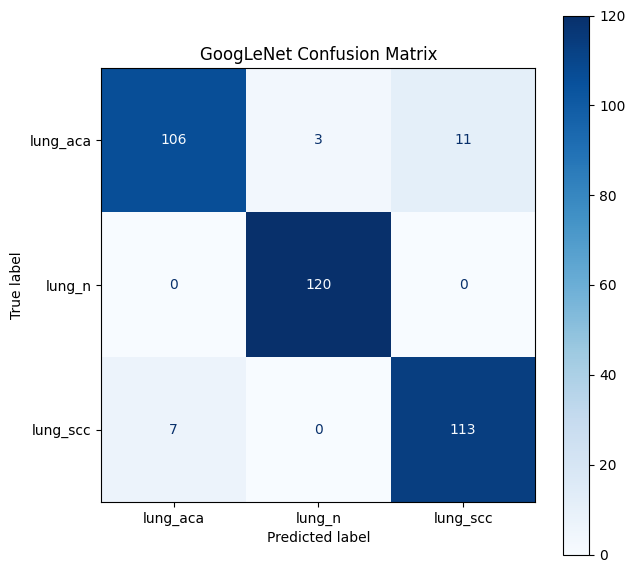

In [33]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title(
    "GoogLeNet Confusion Matrix"
)

plt.show()

In [34]:
torch.save(
    model.state_dict(),
    "lung_cancer_googlenet.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [41]:
from PIL import Image

image_path = r"/content/drive/MyDrive/Deep Learning/split_dataset/test/lung_aca/lungaca1460.jpeg"
image = Image.open(image_path).convert("RGB")
image_tensor = val_transform(image)
image_tensor = image_tensor.unsqueeze(0)
image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    if isinstance(output, tuple):
        output = output[0]

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

confidence = (
    probabilities[0][predicted_class].item()
)

print(
    "Predicted class:",
    test_dataset.classes[predicted_class]
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

Predicted class: lung_aca
Confidence: 71.85%
